In [1]:
import numpy as np

Hilbert space dimension: 243
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Initial state (quspin codes): 20121
Initial state (m values):     +1 -1 +0 +1 +0
Random alternating state: 20121
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


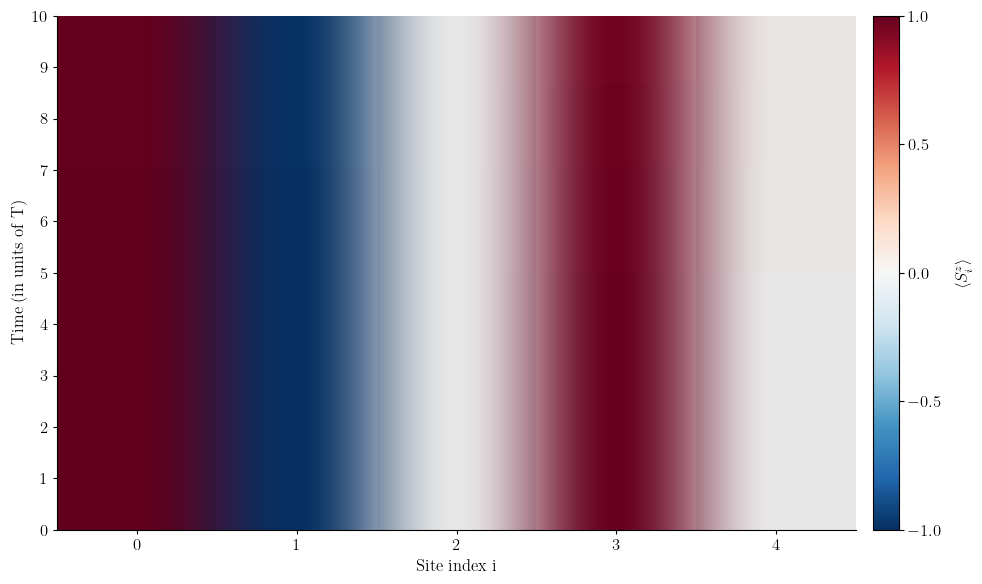

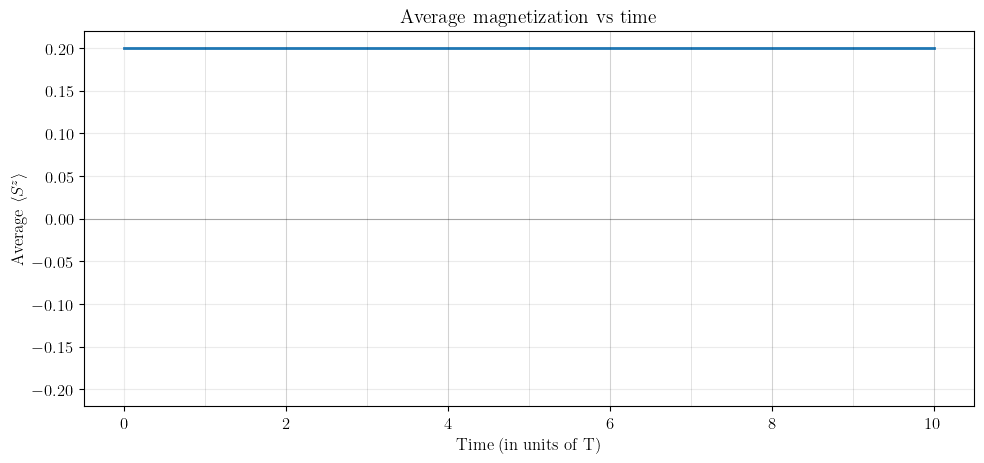

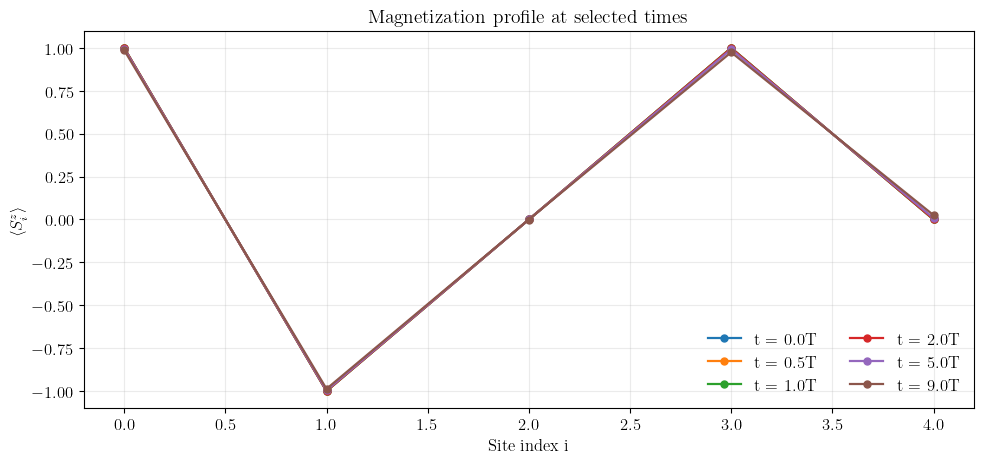


Simulation parameters:
Number of sites: 5
Hopping strength J: 1.0
Driving amplitude V0: 1000.0
Driving period T: 0.006283185307179587
V0/J ratio: 1000.0
Number of periods simulated: 10
Time step dt: 0.00012566370614359174

Initial average magnetization: 0.2000
Final average magnetization: 0.2000
Max |<S^z>|: 1.0000
Min |<S^z>|: 0.0000


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
from quspin.tools.evolution import evolve  # not strictly needed, but handy
import scipy.sparse as sp
# --------------------
# System parameters
# --------------------
L = 5          # number of sites
J = 1.0         # hopping strength
V0 = 1000.0 * J   # driving amplitude (V0 >> J)
T_period = 2.0*np.pi  / V0  # driving period to freezing: 2.0*np.pi  / V0

# --------------------
# Time parameters
# --------------------
n_periods = 10
dt = T_period / 50
times = np.arange(0.0, n_periods * T_period + 1e-12, dt)  # tiny eps to include endpoint
n_times = len(times)

# --------------------
# Basis (spin-1 chain)
# --------------------
basis = spin_basis_1d(L, S="1", pauli=0)  # S^a operators (not Pauli matrices)
print(f"Hilbert space dimension: {basis.Ns}")

# --------------------
# Operators
# --------------------
# H1 = J * sum_i (S^+_i S^-_{i+1} + S^-_i S^+_{i+1}) with PBC
hop_coupling = [
    ["+-", [[J, i, (i+1) % L] for i in range(L)]],
    ["-+", [[J, i, (i+1) % L] for i in range(L)]],
]
H1 = hamiltonian(hop_coupling, [], basis=basis, dtype=np.complex128)

# H2(t) = V(t) * sum_i (S^z_i)^2
# For spin-1, (S^z)^2 has eigenvalues 1 on |±1> and 0 on |0>.
# QuSpin allows onsite "zz" with same site twice: [i, i].
onsite_zz = [[1.0, i, i] for i in range(L)]
# --- replace the square_wave and dynamic_list parts ---

# driving function must be f(t, *args) with positional args
def square_wave(t, T, amp):
    t_mod = t % T
    return (-amp) if (t_mod <= T/2.0) else (amp)

dynamic_list = [
    ["zz", onsite_zz, square_wave, [T_period, V0]],  # args as a list, not dict
]

H = hamiltonian(hop_coupling, dynamic_list, basis=basis, dtype=np.complex128)

# Initial product state: alternating |+1> or |-1> and |0>
# spin-1 string code: "0"->m=-1, "1"->m=0, "2"->m=+1
# --------------------
# --------------------
# Initial product state: ask the user
# spin-1 string code: "0"->m=-1, "1"->m=0, "2"->m=+1
# --------------------
rng = np.random.default_rng(seed=123)

def build_alt_state(L, rng):
    s = []
    for i in range(L):
        if i % 2 == 0:
            s.append(rng.choice(["0", "2"]))  # ±1
        else:
            s.append("1")                      # 0
    return "".join(s)

def parse_user_state(text, L):
    t = text.strip().lower()

    if t == "alt":
        return build_alt_state(L, rng)

    if t == "random":
        # fully random per site in {-1,0,+1}
        map_code = {"-1": "0", "0": "1", "+1": "2"}
        s = "".join(map_code[str(rng.choice([-1, 0, +1]))] for _ in range(L))
        return s

    # case A: raw quspin string like "20120"
    if set(t) <= set("012") and len(t) == L:
        return t

    # case B: space/comma separated m values like "-1 0 +1 -1 0"
    tokens = t.replace(",", " ").split()
    if len(tokens) == L:
        mapped = []
        for tok in tokens:
            tok = tok.strip().replace("＋", "+").replace("−", "-")  # handle unicode signs
            if tok in {"-1", "-"}:
                mapped.append("0")
            elif tok in {"0"}:
                mapped.append("1")
            elif tok in {"+1", "+", "1"}:
                mapped.append("2")
            else:
                raise ValueError(f"invalid spin value '{tok}', use -1, 0, or +1")
        return "".join(mapped)

    raise ValueError("could not parse the state; provide a length-L '012' string or L spins in {-1,0,+1}")

# prompt the user
prompt = (
    f"Enter initial spin-1 product state for L={L}.\n"
    f"- as '012' string (0→-1, 1→0, 2→+1), e.g. 20121\n"
    f"- or L values in {{-1,0,+1}}, e.g. -1 0 +1 -1 0\n"
    f"- or 'alt' (even: ±1 random, odd: 0), or 'random'\n"
    f"State: "
)

try:
    user_text = input(prompt)
    state_str = parse_user_state(user_text, L)
except Exception as e:
    print(f"[warning] {e}. using fallback 'alt' pattern.")
    state_str = build_alt_state(L, rng)

# build |psi0>
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[basis.index(state_str)] = 1.0

# pretty print chosen state in both codes
code_to_m = {"0": -1, "1": 0, "2": +1}
m_list = [code_to_m[c] for c in state_str]
print(f"Initial state (quspin codes): {state_str}")
print(f"Initial state (m values):     {' '.join(f'{m:+d}' for m in m_list)}")


print(f"Random alternating state: {state_str}")

# --------------------
# Measurement operators: S^z_i
# --------------------
Sz_ops = [hamiltonian([["z", [[1.0, i]]]], [], basis=basis, dtype=np.complex128) for i in range(L)]

# --------------------
# Full time evolution with dynamic Hamiltonian
# H.evolve supports an array of times for time-dependent H.
# It returns states at each time in 'times'.
# --------------------
psi_t = H.evolve(psi0, 0.0, times)  # shape (n_times, Ns)

# --------------------
# Expectations
# --------------------
Sz_expect = np.zeros((L, n_times))
for t_idx, psi in enumerate(H.evolve(psi0, 0.0, times, iterate=True)):
    for i in range(L):
        Sz_expect[i, t_idx] = np.real(Sz_ops[i].expt_value(psi))


# --------------------
# Plots (refined: use imshow heatmap)
# --------------------
i# --- Space–time heatmap styled like your image ---
from matplotlib.colors import TwoSlopeNorm

tT = times / T_period

fig, ax = plt.subplots(figsize=(10, 6))

# alternating column shading for readability
for col in range(L):
    if col % 2 == 0:
        ax.axvspan(col-0.5, col+0.5, color='k', alpha=0.06, lw=0)

im = ax.imshow(
    Sz_expect.T,
    origin='lower',
    aspect='auto',
    extent=[-0.5, L-0.5, tT[0], tT[-1]],
    cmap='RdBu_r',
    norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
)

# axes look
ax.set_facecolor('white')
ax.set_xticks(np.arange(L))
ax.set_xlabel('Site index i', fontsize=12)
ax.set_ylabel('Time (in units of T)', fontsize=12)
ax.tick_params(axis='both', which='both', length=3, width=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# tidy period ticks on y
ax.set_yticks(np.arange(0, n_periods+1, 1))

# slim colorbar on the right
cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.05)
cbar.set_label(r'$\langle S^z_i \rangle$', rotation=90, labelpad=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.outline.set_linewidth(0.8)

fig.tight_layout()
plt.show()


# 2) Average magnetization vs time (no offset notation)
fig, ax = plt.subplots(figsize=(10, 4.8))
avg_Sz = np.mean(Sz_expect, axis=0)
ax.plot(tT, avg_Sz, lw=2)

ax.set_xlabel('Time (in units of T)', fontsize=12)
ax.set_ylabel(r'Average $\langle S^z \rangle$', fontsize=12)
ax.set_title('Average magnetization vs time', fontsize=14)

# turn off offset like "1e-1 + …"
ax.ticklabel_format(useOffset=False, style='plain', axis='y')

# show zero line
ax.axhline(0, color='k', lw=0.8, alpha=0.3)

# faint vertical guides at periods
for k in range(1, n_periods + 1):
    ax.axvline(x=k, color='k', lw=0.5, alpha=0.15)

# auto scale but avoid huge symmetric limits if nearly flat:
span = np.max(np.abs(avg_Sz))
if span < 1e-3:
    ax.set_ylim(-1.5e-3, 1.5e-3)
else:
    ax.set_ylim(-1.1*span, 1.1*span)

ax.grid(alpha=0.25)
fig.tight_layout()

# 3) Magnetization profile snapshots
fig, ax = plt.subplots(figsize=(10, 4.8))
time_snapshots = [0, T_period/2, T_period, 2*T_period, 5*T_period, 9*T_period]

for t_snap in time_snapshots:
    t_idx = int(round(t_snap / dt))
    if 0 <= t_idx < n_times:
        ax.plot(range(L), Sz_expect[:, t_idx], 'o-', lw=1.6, ms=5,
                label=f't = {t_snap/T_period:.1f}T')

ax.set_xlabel('Site index i', fontsize=12)
ax.set_ylabel(r'$\langle S^z_i \rangle$', fontsize=12)
ax.set_title('Magnetization profile at selected times', fontsize=14)
ax.set_ylim(-1.1, 1.1)
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

plt.show()


# --------------------
# Diagnostics
# --------------------
print("\nSimulation parameters:")
print(f"Number of sites: {L}")
print(f"Hopping strength J: {J}")
print(f"Driving amplitude V0: {V0}")
print(f"Driving period T: {T_period}")
print(f"V0/J ratio: {V0/J}")
print(f"Number of periods simulated: {n_periods}")
print(f"Time step dt: {dt}")
print(f"\nInitial average magnetization: {np.mean(Sz_expect[:, 0]):.4f}")
print(f"Final average magnetization: {np.mean(Sz_expect[:, -1]):.4f}")
print(f"Max |<S^z>|: {np.max(np.abs(Sz_expect)):.4f}")
print(f"Min |<S^z>|: {np.min(np.abs(Sz_expect)):.4f}")


# 1D Heisenberg

In [7]:
from quspin.operators import hamiltonian
# system size / number of spins
L = 10

# define couplings
Jxy, Jzz = 1.0, 1.0
hz, hx = 1.0, 1.0

# compute basis
basis_ising = spin_basis_1d(L=L,)

# define site-coupling lists
Jzz_list = [[Jzz, j,j+1] for j in range(L-1)] # L-1 bonds
hz_list = [[hz,j] for j in range(L)] # L sites
hx_list = [[hx,j] for j in range(L)] # L sites

# define Hamiltonian terms
H_terms = [['zz',Jzz_list],
		   ['x',hx_list],
		   ['z',hz_list],
		  ]
H_Ising = hamiltonian(H_terms,[], basis=basis_ising)

# cast to array
print('\nIsing Hamiltonian matrix:\n {}\n'.format(H_Ising.toarray()) )
print('\nIsing Hamiltonian matrix:\n {}\n'.format(H_Ising.shape) )

# compute eigenenergies and eigenstates
E, V = H_Ising.eigh()
# ground state
psi_GS = V[:,0]
E_GS = E[0]
print('\nGS energy = {}'.format(E_GS) )
# first-excited state
psi_ex_1 = V[:,1]
E_exc = E[1]
print('\nfirst excited state energy = {}\n'.format(E_exc) )

Hermiticity check passed!
Symmetry checks passed!

Ising Hamiltonian matrix:
 [[19.+0.j  1.+0.j  1.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 [ 1.+0.j 15.+0.j  0.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 [ 1.+0.j  0.+0.j 13.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 ...
 [ 0.+0.j  0.+0.j  0.+0.j ... -3.+0.j  0.+0.j  1.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j ...  0.+0.j -1.+0.j  1.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j ...  1.+0.j  1.+0.j -1.+0.j]]


Ising Hamiltonian matrix:
 (1024, 1024)


GS energy = -13.572021834189933

first excited state energy = -12.990977106165644



# 2D lattice of spin-s

In [78]:
import numpy as np
from quspin.basis import spin_basis_1d, spin_basis_general
from quspin.operators import hamiltonian

Lx, Ly = 3, 3  # linear dimension of spin 1/2 2d lattice
U, mu = 10, 1
S,Sstr = 1., "1"

N_2d = Lx * Ly  # number of sites for spin 1/2
s = np.arange(N_2d)  # sites [0,1,2,....]
x = s % Lx  # x positions for sites
y = s // Lx  # y positions for sites
T_x = (x + 1) % Lx + Lx * y  # translation along x-direction
T_y = x + Lx * ((y + 1) % Ly)  # translation along y-direction
P_x = x + Lx * (Ly - y - 1)  # reflection about x-axis
P_y = (Lx - x - 1) + Lx * y  # reflection about y-axis
Z = -(s + 1)  # spin inversion

In [79]:
###### setting up bases ######

basis_2d = spin_basis_general(
    N_2d,
    # kxblock=(T_x, 0),
    # kyblock=(T_y, 0),
    # pxblock=(P_x, 0),
    # pyblock=(P_y, 0),
    S=Sstr
)  # 2d - basis

print("Size of 2D H-space: {Ns:d}".format(Ns=basis_2d.Ns))

###### setting up operators in hamiltonian ######

# setting up hamiltonians

# 2d (nx)
hI_2d = [[S*mu, i] for i in range(N_2d)]
hz_2d = [[mu, i] for i in range(N_2d)]
Hz_2d  = hamiltonian([["I", hI_2d]], [], basis=basis_2d, dtype=np.float64)
Hz_2d -= hamiltonian([["z", hz_2d]], [], basis=basis_2d, dtype=np.float64)

# 2d (nx ny)
JII_2d = [[S**2 * U, i, T_x[i]] for i in range(N_2d)] + [[S**2 * U, i, T_y[i]] for i in range(N_2d)]
JIz_2d = [[S * U, i, T_x[i]] for i in range(N_2d)] + [[S * U, i, T_y[i]] for i in range(N_2d)]
Jzz_2d = [[U, i, T_x[i]] for i in range(N_2d)] + [[U, i, T_y[i]] for i in range(N_2d)]
Hzz_2d  = hamiltonian([["II", JII_2d]], [], basis=basis_2d, dtype=np.float64)
Hzz_2d -= hamiltonian([["zI", JIz_2d], ["Iz", JIz_2d]], [], basis=basis_2d, dtype=np.float64)
Hzz_2d += hamiltonian([["zz", Jzz_2d]], [], basis=basis_2d, dtype=np.float64)

Htot = Hz_2d + Hzz_2d


Size of 2D H-space: 19683
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


In [80]:
diag = Htot.diagonal() 
argm = np.argmin(diag)
print(diag)
print(diag)
print(diag[argm])
print(argm)

[  0.   1.   2. ... 576. 657. 738.]
[  0.   1.   2. ... 576. 657. 738.]
0.0
0


In [95]:
particle_number = [int(ch) for ch in np.base_repr(basis_2d[argm], base=3)]
print(particle_number)

[2, 2, 2, 2, 2, 2, 2, 2, 2]


In [81]:
print(basis_2d.int_to_state(basis_2d[argm]))
#basis_2d.states[argm])
# basis_2d

|2 2 2 2 2 2 2 2 2>


In [123]:
from quspin.operators import exp_op
import scipy
# construct gibbs state


dtype_real = np.float64
list_beta = np.logspace(-2, 2, num=9)

print(list_beta)
all_avg_particle_number = []
for beta in list_beta:
    exp_Htot_diag = np.exp(-beta * Htot.diagonal())
    traceless_exp_Htot_diag = exp_Htot_diag / exp_Htot_diag.sum()

    all_particle_number = np.zeros((len(traceless_exp_Htot_diag), N_2d))
    for index, state, proba in zip(range(len(traceless_exp_Htot_diag)), basis_2d, traceless_exp_Htot_diag):
        str_repr = [int(ch) for ch in np.base_repr(state, base=3)]
        all_particle_number[index, :] = np.array([0,]*(N_2d - len(str_repr)) + str_repr) * proba

    avg_particle_number = np.sum(all_particle_number, axis=0)
    all_avg_particle_number.append(avg_particle_number)


    



[1.00000000e-02 3.16227766e-02 1.00000000e-01 3.16227766e-01
 1.00000000e+00 3.16227766e+00 1.00000000e+01 3.16227766e+01
 1.00000000e+02]


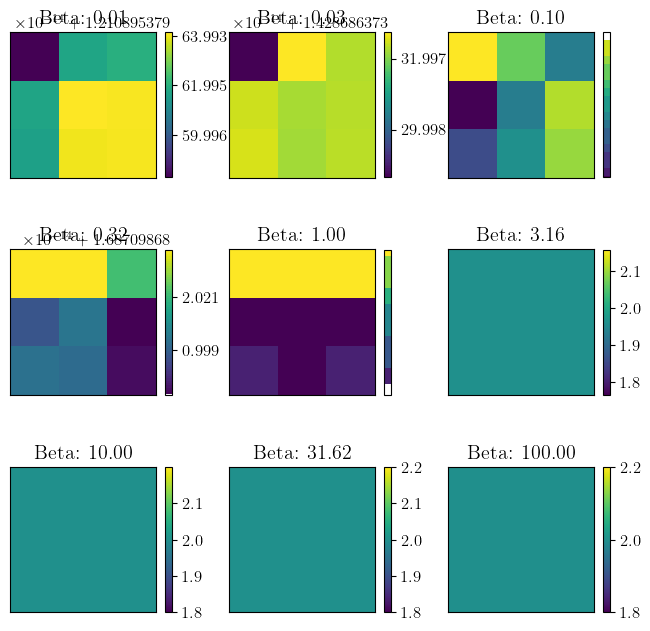

In [ ]:
import matplotlib.pyplot as plt
# print(all_avg_particle_number)

ncols = 3
fig, ax = plt.subplots(ncols = ncols, nrows=len(list_beta)//ncols, figsize = (8, 8))
for ii, beta, avg_particle_number in zip(range(len(list_beta)), list_beta, all_avg_particle_number):
    img = ax[ii//ncols][ii%ncols].imshow(avg_particle_number.reshape((3, 3)))
    ax[ii//ncols][ii%ncols].set_title(f"Beta: {beta:.02f}")
    ax[ii//ncols][ii%ncols].set_xticks([])
    ax[ii//ncols][ii%ncols].set_yticks([])
    fig.colorbar(img, ax=ax[ii//ncols][ii%ncols], shrink=0.8)
# plt.plot(list_beta, all_avg_particle_number)

fig.tight_layout()